
✓ Custo esperado: R$ 9.2734

 base (π=0.34)
 Hora  Rede_compra  Rede_venda   PV  Demanda  BESS_carga  BESS_descarga  E_BESS  state
    0         1.93         0.0 0.00     1.93        0.00           0.00    0.00      0
    1         1.61         0.0 0.00     1.61        0.00           0.00   -0.00      0
    2         1.41         0.0 0.00     1.41        0.00           0.00   -0.00      0
    3         1.33         0.0 0.00     1.33        0.00           0.00   -0.00      0
    4         1.30         0.0 0.08     1.38        0.00           0.00   -0.00      0
    5         1.18         0.0 0.46     1.64        0.00           0.00   -0.00      0
    6         0.87         0.0 1.07     1.94        0.00           0.00   -0.00      0
    7         0.16         0.0 1.58     1.74        0.00           0.00   -0.00      0
    8         0.00         0.0 2.43     1.83        0.60           0.00    0.53      0
    9         0.00         0.0 2.75     1.84        0.91           0.00    1.34      

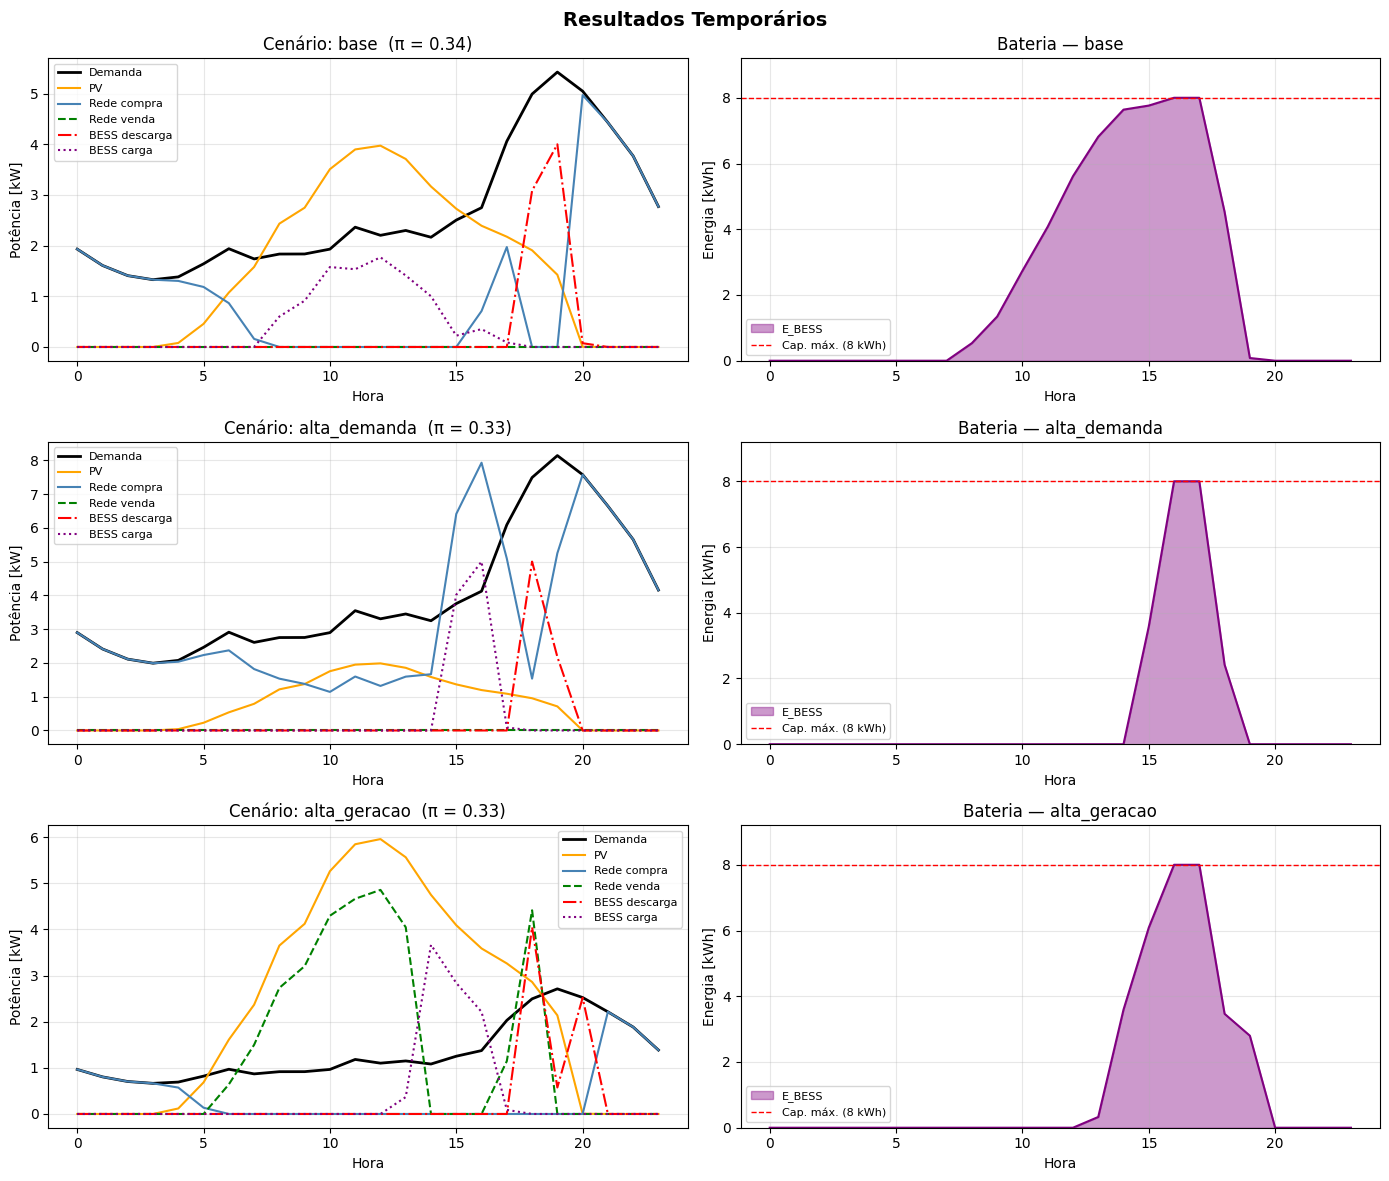

In [ ]:
from pyomo.opt import SolverFactory, SolverStatus, TerminationCondition
import pyomo.environ as pyo
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

#
# ── Dados ──────────────────────────────────────────────────────────────────────
P_demand_data = [
    1.9317, 1.6090, 1.4079, 1.3281, 1.3834, 1.6413,
    1.9395, 1.7383, 1.8341, 1.8354, 1.9312, 2.3645,
    2.2038, 2.2997, 2.1659, 2.5046, 2.7490, 4.0597,
    4.9924, 5.4257, 5.0491, 4.4294, 3.7692, 2.7716
]
P_pv_data = [
    0.0000, 0.0000, 0.0000, 0.0000, 0.0796, 0.4565,
    1.0742, 1.5790, 2.4343, 2.7488, 3.5092, 3.8988,
    3.9734, 3.7105, 3.1671, 2.7282, 2.3926, 2.1764,
    1.9083, 1.4257, 0.0034, 0.0000, 0.0000, 0.0000
]
tariff_buy = [
    0.22419, 0.22419, 0.22419, 0.22419, 0.22419, 0.22419,
    0.22419, 0.22419, 0.22419, 0.22419, 0.22419, 0.22419,
    0.22419, 0.22419, 0.22419, 0.22419, 0.22419, 0.32629,
    0.51792, 0.51792, 0.51792, 0.32629, 0.22419, 0.22419
]
parameters = {
    "Grid": {"Pmax": 90},
    "BESS": {
        "Pmax": 5.0,
        "eff": 0.90,
        "self_discharge": 0.01,
        "capacity": 8,
        "initial capacity": 0,
    }
}
scenarios = {
    "base": {
        "P_demand": P_demand_data,
        "P_pv":     P_pv_data,
        "prob":     0.34,
    },
    "alta_demanda": {
        "P_demand": [round(x * 1.5, 4) for x in P_demand_data],
        "P_pv":     [round(x * 0.5, 4) for x in P_pv_data],
        "prob":     0.33,
    },
    "alta_geracao": {
        "P_demand": [round(x * 0.5, 4) for x in P_demand_data],
        "P_pv":     [round(x * 1.5, 4) for x in P_pv_data],
        "prob":     0.33,
    },
}


class SmartHomeStochastic:
    def __init__(self, parameters, scenarios, tariff_buy):
        # Atributos do objeto — precisam de self para sobreviver entre métodos
        self.parameters = parameters
        self.scenarios  = scenarios
        self.tariff_buy = tariff_buy
        self.results    = {}        # será preenchido em solve()

    def build(self):
        m     = pyo.ConcreteModel('SmartHome_Stochastic')
        delta = 1.0

        # Conjuntos
        m.T = pyo.RangeSet(0, len(self.tariff_buy) - 1)
        m.S = pyo.Set(initialize=self.scenarios.keys())

        # Parâmetros [matrizes]
        m.P_demand = pyo.Param(m.S, m.T,
                               initialize=lambda m, s, t: self.scenarios[s]['P_demand'][t])
        m.P_pv     = pyo.Param(m.S, m.T,
                               initialize=lambda m, s, t: self.scenarios[s]['P_pv'][t])
        m.prob     = pyo.Param(m.S,
                               initialize=lambda m, s: self.scenarios[s]['prob'])
        m.tariff   = pyo.Param(m.T,
                               initialize=lambda m, t: self.tariff_buy[t])

        # Parâmetros BESS — variáveis locais: só existem dentro de build()
        Pmax_bess = self.parameters['BESS']['Pmax']
        eff       = self.parameters['BESS']['eff']
        beta      = self.parameters['BESS']['self_discharge']
        init_cap  = self.parameters['BESS']['initial capacity']
        Pmax_grid = self.parameters['Grid']['Pmax']

        # Variáveis de 2ª etapa (indexadas por cenário e tempo)
        m.Pgrid_buy       = pyo.Var(m.S, m.T, within=pyo.NonNegativeReals, bounds=(0, Pmax_grid))
        m.Pgrid_sell      = pyo.Var(m.S, m.T, within=pyo.NonNegativeReals, bounds=(0, Pmax_grid))
        m.Pgrid           = pyo.Var(m.S, m.T, within=pyo.Reals,            bounds=(-Pmax_grid, Pmax_grid))
        m.Pbess_charge    = pyo.Var(m.S, m.T, within=pyo.NonNegativeReals, bounds=(0, Pmax_bess))
        m.Pbess_discharge = pyo.Var(m.S, m.T, within=pyo.NonNegativeReals, bounds=(0, Pmax_bess))
        m.E_bess          = pyo.Var(m.S, m.T, within=pyo.NonNegativeReals, bounds=(0, parameters['BESS']['capacity']))

        # Variável de 1ª etapa (SEM índice s — mesma para todos os cenários)
        m.state = pyo.Var(m.T, within=pyo.Binary)

        # Restrições
        def power_balance_rule(m, s, t): # Balanço de potência
            return (+ m.Pgrid[s, t] 
                    + m.P_pv[s, t] 
                    + m.Pbess_discharge[s, t]
                    == 
                    + m.P_demand[s, t] 
                    + m.Pbess_charge[s, t])
        m.power_balance = pyo.Constraint(m.S, m.T, rule=power_balance_rule)

        def grid_balance_rule(m, s, t): # Potencia liquida
            return m.Pgrid[s, t] == m.Pgrid_buy[s, t] - m.Pgrid_sell[s, t]
        m.grid_balance = pyo.Constraint(m.S, m.T, rule=grid_balance_rule)

        def bess_energy_rule(m, s, t): # Continuidade de energia da bateria
            charge    = eff * delta * m.Pbess_charge[s, t]
            discharge = delta * m.Pbess_discharge[s, t] / eff
            loss      = beta * delta * m.E_bess[s, t]

            if t == 0:
                E_prev = init_cap
            else:
                E_prev = m.E_bess[s, t-1]
            return m.E_bess[s, t] == E_prev + charge - discharge - loss
        m.bess_energy = pyo.Constraint(m.S, m.T, rule=bess_energy_rule)
        
        # Não simultaneidade carga/descarga
        def bess_discharge_limit(m, s, t):
            return m.Pbess_discharge[s, t] <= Pmax_bess * m.state[t]
        m.dis_limit = pyo.Constraint(m.S, m.T, rule=bess_discharge_limit)

        def bess_charge_limit(m, s, t):
            return m.Pbess_charge[s, t] <= Pmax_bess * (1 - m.state[t])
        m.ch_limit = pyo.Constraint(m.S, m.T, rule=bess_charge_limit)

        def objective_rule(m):
            return delta * sum(
                m.prob[s] * sum(
                    m.tariff[t] * m.Pgrid_buy[s, t] - 0.7 * m.tariff[t] * m.Pgrid_sell[s, t]
                    for t in m.T
                )
                for s in m.S
            )
        m.objective = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

        self.model = m  # guarda no objeto para ser acessado em solve() e plot()

    def solve(self):
        solver   = SolverFactory('highs')
        solution = solver.solve(self.model)

        if (solution.solver.status == SolverStatus.ok and
                solution.solver.termination_condition == TerminationCondition.optimal):
            print(f"\n✓ Custo esperado: R$ {pyo.value(self.model.objective):.4f}")
        else:
            print("✗ Solver não encontrou solução ótima.")
            print(f"  Status: {solution.solver.status}")
            print(f"  Termination: {solution.solver.termination_condition}")
            return

        # Coleta resultados em self.results para o plot usar depois
        # self.results é um dicionário: { nome_cenario: DataFrame }
        for s in self.model.S:
            rows = []
            for t in self.model.T:
                rows.append({
                    'Hora':            t,
                    'Rede_compra':     pyo.value(self.model.Pgrid_buy[s, t]),
                    'Rede_venda':      pyo.value(self.model.Pgrid_sell[s, t]),
                    'PV':              pyo.value(self.model.P_pv[s, t]),
                    'Demanda':         pyo.value(self.model.P_demand[s, t]),
                    'BESS_carga':      pyo.value(self.model.Pbess_charge[s, t]),
                    'BESS_descarga':   pyo.value(self.model.Pbess_discharge[s, t]),
                    'E_BESS':          pyo.value(self.model.E_bess[s, t]),
                    'state':           int(pyo.value(self.model.state[t])),
                })

            # df é local — só existe dentro deste for, por isso sem self
            df = pd.DataFrame(rows)
            print(f"\n {s} (π={self.scenarios[s]['prob']})")
            print(df.round(2).to_string(index=False))

            # Salva no objeto para o plot acessar
            self.results[s] = df

    def plot(self):
        horas     = list(self.model.T)          # [0, 1, ..., 23]
        cenarios  = list(self.results.keys())   # ['base', 'alta_demanda', 'alta_geracao']
        n         = len(cenarios)

        # Uma linha por cenário, 2 colunas: fluxos de potência | estado da bateria
        fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(14, 4 * n), sharey=False)
        fig.suptitle("Resultados preliminares", fontsize=14, fontweight='bold')

        for i, s in enumerate(cenarios):
            df  = self.results[s]       # self.results existe porque foi preenchido em solve()
            ax1 = axes[i, 0]            # coluna esquerda: fluxos de potência
            ax2 = axes[i, 1]            # coluna direita:  energia da bateria

            prob = self.scenarios[s]['prob']

            # ── Gráfico esquerdo: fluxos de potência ──────────────────────────
            ax1.plot(horas, df['Demanda'],       label='Demanda',      color='black',  linewidth=2)
            ax1.plot(horas, df['PV'],            label='PV',           color='orange', linewidth=1.5)
            ax1.plot(horas, df['Rede_compra'],   label='Rede compra',  color='steelblue', linewidth=1.5)
            ax1.plot(horas, df['Rede_venda'],    label='Rede venda',   color='green',  linewidth=1.5, linestyle='--')
            ax1.plot(horas, df['BESS_descarga'], label='BESS descarga',color='red',    linewidth=1.5, linestyle='-.')
            ax1.plot(horas, df['BESS_carga'],    label='BESS carga',   color='purple', linewidth=1.5, linestyle=':')

            ax1.set_title(f"Cenário: {s}  (π = {prob})")
            ax1.set_ylabel("Potência [kW]")
            ax1.set_xlabel("Hora")
            ax1.legend(fontsize=8)
            ax1.grid(True, alpha=0.3)

            # ── Gráfico direito: energia armazenada na bateria ────────────────
            ax2.fill_between(horas, df['E_BESS'], alpha=0.4, color='purple', label='E_BESS')
            ax2.plot(horas, df['E_BESS'], color='purple', linewidth=1.5)

            # Linha de capacidade máxima para referência
            cap_max = self.parameters['BESS']['capacity']
            ax2.axhline(cap_max, color='red', linestyle='--', linewidth=1, label=f'Cap. máx. ({cap_max} kWh)')

            ax2.set_title(f"Bateria — {s}")
            ax2.set_ylabel("Energia [kWh]")
            ax2.set_xlabel("Hora")
            ax2.set_ylim(0, cap_max * 1.15)
            ax2.legend(fontsize=8)
            ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


# ── Execução ───────────────────────────────────────────────────────────────────
sh = SmartHomeStochastic(parameters, scenarios, tariff_buy)
sh.build()
sh.solve()
sh.plot()

O caso acima é avalia o comportamento da bateria em cada cenário

O caso abaixo achará o comportamento ótimo da bateria para qualquer cenário


✓ Custo esperado: R$ 9.3287

 base (π=0.34)
 Hora  Rede_compra  Rede_venda   PV  Demanda  BESS_carga  BESS_descarga  E_BESS  state
    0         1.93         0.0 0.00     1.93        0.00           0.00    0.00      0
    1         1.61         0.0 0.00     1.61        0.00          -0.00    0.00      0
    2         1.41         0.0 0.00     1.41        0.00          -0.00    0.00      0
    3         1.33         0.0 0.00     1.33        0.00          -0.00    0.00      0
    4         1.30         0.0 0.08     1.38        0.00          -0.00    0.00      0
    5         1.18         0.0 0.46     1.64        0.00          -0.00    0.00      0
    6         0.87         0.0 1.07     1.94        0.00           0.00   -0.00      0
    7         0.16         0.0 1.58     1.74        0.00           0.00   -0.00      0
    8         0.00         0.0 2.43     1.83        0.60           0.00    0.53      0
    9         0.00         0.0 2.75     1.84        0.91           0.00    1.34      

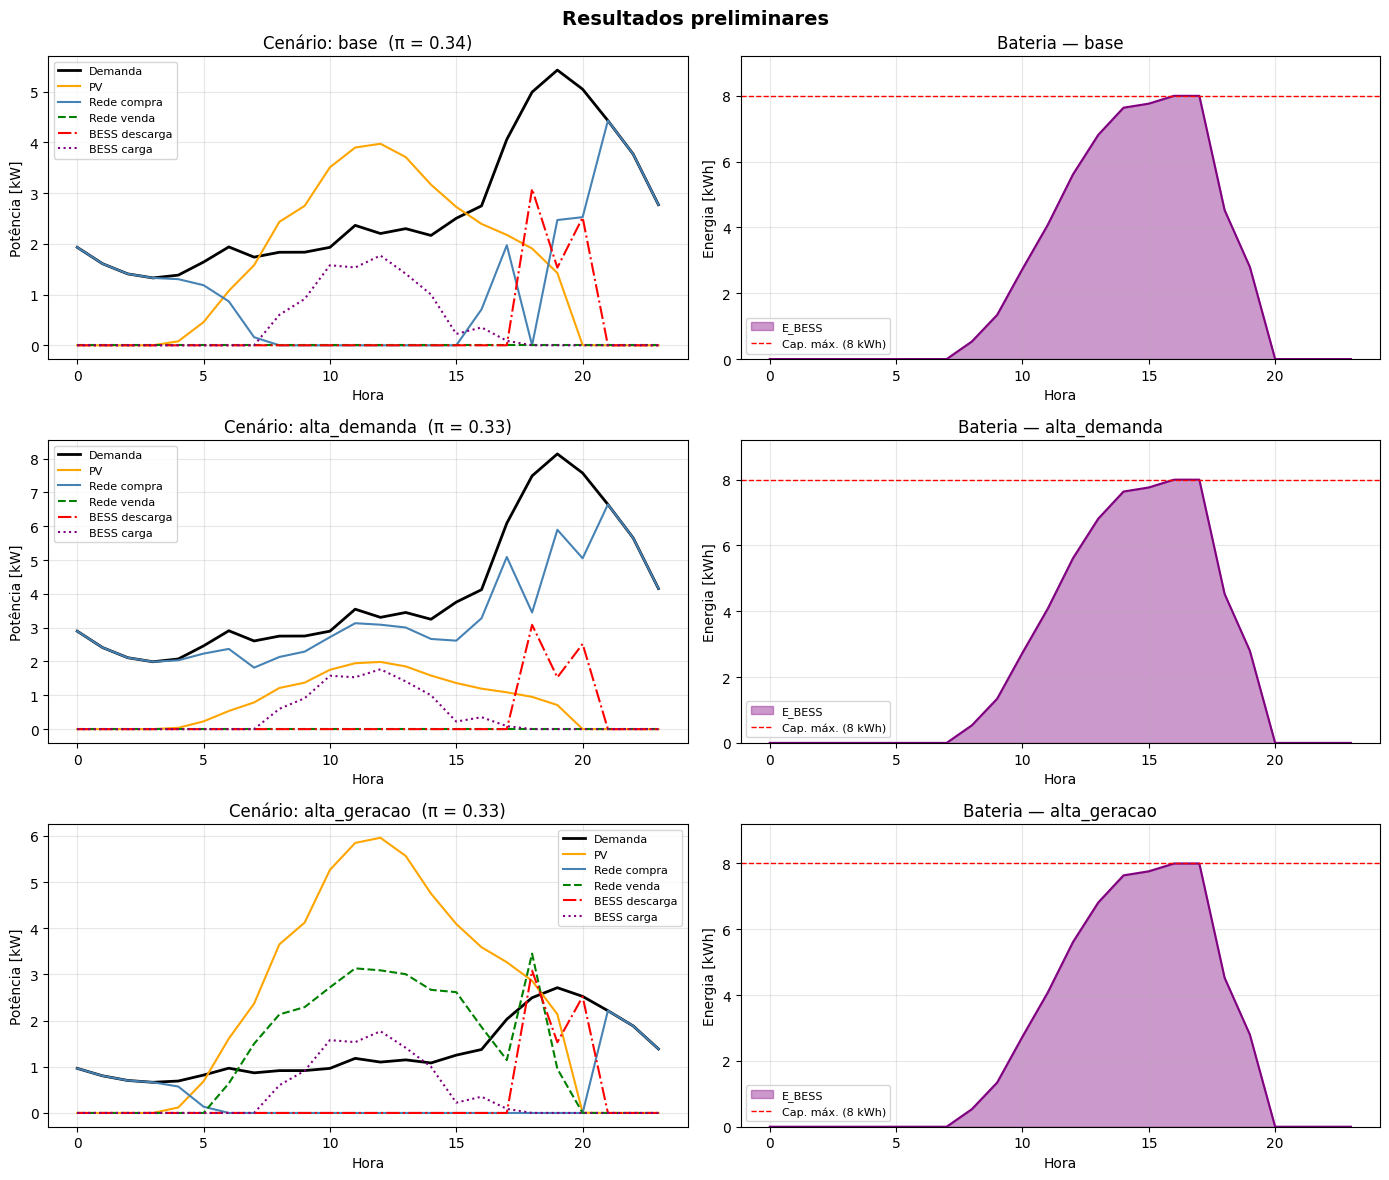

In [4]:
from pyomo.opt import SolverFactory, SolverStatus, TerminationCondition
import pyomo.environ as pyo
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Dados ──────────────────────────────────────────────────────────────────────
P_demand_data = [
    1.9317, 1.6090, 1.4079, 1.3281, 1.3834, 1.6413,
    1.9395, 1.7383, 1.8341, 1.8354, 1.9312, 2.3645,
    2.2038, 2.2997, 2.1659, 2.5046, 2.7490, 4.0597,
    4.9924, 5.4257, 5.0491, 4.4294, 3.7692, 2.7716
]
P_pv_data = [
    0.0000, 0.0000, 0.0000, 0.0000, 0.0796, 0.4565,
    1.0742, 1.5790, 2.4343, 2.7488, 3.5092, 3.8988,
    3.9734, 3.7105, 3.1671, 2.7282, 2.3926, 2.1764,
    1.9083, 1.4257, 0.0034, 0.0000, 0.0000, 0.0000
]
tariff_buy = [
    0.22419, 0.22419, 0.22419, 0.22419, 0.22419, 0.22419,
    0.22419, 0.22419, 0.22419, 0.22419, 0.22419, 0.22419,
    0.22419, 0.22419, 0.22419, 0.22419, 0.22419, 0.32629,
    0.51792, 0.51792, 0.51792, 0.32629, 0.22419, 0.22419
]
parameters = {
    "Grid": {"Pmax": 90},
    "BESS": {
        "Pmax": 5.0,
        "eff": 0.90,
        "self_discharge": 0.01,
        "capacity": 8,
        "initial capacity": 0,
    }
}
scenarios = {
    "base": {
        "P_demand": P_demand_data,
        "P_pv":     P_pv_data,
        "prob":     0.34,
    },
    "alta_demanda": {
        "P_demand": [round(x * 1.5, 4) for x in P_demand_data],
        "P_pv":     [round(x * 0.5, 4) for x in P_pv_data],
        "prob":     0.33,
    },
    "alta_geracao": {
        "P_demand": [round(x * 0.5, 4) for x in P_demand_data],
        "P_pv":     [round(x * 1.5, 4) for x in P_pv_data],
        "prob":     0.33,
    },
}


class SmartHomeStochastic:
    def __init__(self, parameters, scenarios, tariff_buy):
        # Atributos do objeto — precisam de self para sobreviver entre métodos
        self.parameters = parameters
        self.scenarios  = scenarios
        self.tariff_buy = tariff_buy
        self.results    = {}        # será preenchido em solve()

    def build(self):
        m     = pyo.ConcreteModel('SmartHome_Stochastic')
        delta = 1.0

        # Conjuntos
        m.T = pyo.RangeSet(0, len(self.tariff_buy) - 1)
        m.S = pyo.Set(initialize=self.scenarios.keys())

        # Parâmetros [matrizes]
        m.P_demand = pyo.Param(m.S, m.T,
                               initialize=lambda m, s, t: self.scenarios[s]['P_demand'][t])
        m.P_pv     = pyo.Param(m.S, m.T,
                               initialize=lambda m, s, t: self.scenarios[s]['P_pv'][t])
        m.prob     = pyo.Param(m.S,
                               initialize=lambda m, s: self.scenarios[s]['prob'])
        m.tariff   = pyo.Param(m.T,
                               initialize=lambda m, t: self.tariff_buy[t])

        # Parâmetros BESS — variáveis locais: só existem dentro de build()
        Pmax_bess = self.parameters['BESS']['Pmax']
        eff       = self.parameters['BESS']['eff']
        beta      = self.parameters['BESS']['self_discharge']
        init_cap  = self.parameters['BESS']['initial capacity']
        Pmax_grid = self.parameters['Grid']['Pmax']

        # Variáveis de 2ª etapa (indexadas por cenário e tempo)
        m.Pgrid_buy       = pyo.Var(m.S, m.T, within=pyo.NonNegativeReals, bounds=(0, Pmax_grid))
        m.Pgrid_sell      = pyo.Var(m.S, m.T, within=pyo.NonNegativeReals, bounds=(0, Pmax_grid))
        m.Pgrid           = pyo.Var(m.S, m.T, within=pyo.Reals,            bounds=(-Pmax_grid, Pmax_grid))

        # Aqui a bateria opera em função do tempo apenas
        m.Pbess_charge    = pyo.Var(m.T, within=pyo.NonNegativeReals, bounds=(0, Pmax_bess))
        m.Pbess_discharge = pyo.Var(m.T, within=pyo.NonNegativeReals, bounds=(0, Pmax_bess))
        m.E_bess          = pyo.Var(m.T, within=pyo.NonNegativeReals, bounds=(0, parameters['BESS']['capacity']))

        # Variável de 1ª etapa (SEM índice s — mesma para todos os cenários)
        m.state = pyo.Var(m.T, within=pyo.Binary)

        # Restrições
        def power_balance_rule(m, s, t): # Balanço de potência
            return (+ m.Pgrid[s, t] 
                    + m.P_pv[s, t] 
                    + m.Pbess_discharge[t]
                    == 
                    + m.P_demand[s, t] 
                    + m.Pbess_charge[t])
        m.power_balance = pyo.Constraint(m.S, m.T, rule=power_balance_rule)

        def grid_balance_rule(m, s, t): # Potencia liquida
            return m.Pgrid[s, t] == m.Pgrid_buy[s, t] - m.Pgrid_sell[s, t]
        m.grid_balance = pyo.Constraint(m.S, m.T, rule=grid_balance_rule)

        def bess_energy_rule(m, t): # Continuidade de energia da bateria
            charge    = eff * delta * m.Pbess_charge[t]
            discharge = delta * m.Pbess_discharge[t] / eff
            loss      = beta * delta * m.E_bess[t]

            if t == 0:
                E_prev = init_cap
            else:
                E_prev = m.E_bess[t-1]
            return m.E_bess[t] == E_prev + charge - discharge - loss
        m.bess_energy = pyo.Constraint( m.T, rule=bess_energy_rule)
        
        # Não simultaneidade carga/descarga
        def bess_discharge_limit(m, s, t):
            return m.Pbess_discharge[t] <= Pmax_bess * m.state[t]
        m.dis_limit = pyo.Constraint(m.S, m.T, rule=bess_discharge_limit)

        def bess_charge_limit(m, s, t):
            return m.Pbess_charge[t] <= Pmax_bess * (1 - m.state[t])
        m.ch_limit = pyo.Constraint(m.S, m.T, rule=bess_charge_limit)

        # FUNÇÃO OBJETIVO
        def objective_rule(m): 
            return delta * sum(
                m.prob[s] * sum(
                    m.tariff[t] * m.Pgrid_buy[s, t] - 0.7 * m.tariff[t] * m.Pgrid_sell[s, t]
                    for t in m.T
                )
                for s in m.S
            )
        m.objective = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

        self.model = m  # guarda no objeto para ser acessado em solve() e plot()

    def solve(self):
        solver   = SolverFactory('highs')
        solution = solver.solve(self.model)

        if (solution.solver.status == SolverStatus.ok and
                solution.solver.termination_condition == TerminationCondition.optimal):
            print(f"\n✓ Custo esperado: R$ {pyo.value(self.model.objective):.4f}")
        else:
            print("✗ Solver não encontrou solução ótima.")
            print(f"  Status: {solution.solver.status}")
            print(f"  Termination: {solution.solver.termination_condition}")
            return

        # Coleta resultados em self.results para o plot usar depois
        # self.results é um dicionário: { nome_cenario: DataFrame }
        for s in self.model.S:
            rows = []
            for t in self.model.T:
                rows.append({
                    'Hora':            t,
                    'Rede_compra':     pyo.value(self.model.Pgrid_buy[s, t]),
                    'Rede_venda':      pyo.value(self.model.Pgrid_sell[s, t]),
                    'PV':              pyo.value(self.model.P_pv[s, t]),
                    'Demanda':         pyo.value(self.model.P_demand[s, t]),
                    'BESS_carga':      pyo.value(self.model.Pbess_charge[t]),
                    'BESS_descarga':   pyo.value(self.model.Pbess_discharge[t]),
                    'E_BESS':          pyo.value(self.model.E_bess[t]),
                    'state':           int(pyo.value(self.model.state[t])),
                })

            # df é local — só existe dentro deste for, por isso sem self
            df = pd.DataFrame(rows)
            print(f"\n {s} (π={self.scenarios[s]['prob']})")
            print(df.round(2).to_string(index=False))

            # Salva no objeto para o plot acessar
            self.results[s] = df

    def plot(self):
        horas     = list(self.model.T)          # [0, 1, ..., 23]
        cenarios  = list(self.results.keys())   # ['base', 'alta_demanda', 'alta_geracao']
        n         = len(cenarios)

        # Uma linha por cenário, 2 colunas: fluxos de potência | estado da bateria
        fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(14, 4 * n), sharey=False)
        fig.suptitle("Resultados preliminares", fontsize=14, fontweight='bold')

        for i, s in enumerate(cenarios):
            df  = self.results[s]       # self.results existe porque foi preenchido em solve()
            ax1 = axes[i, 0]            # coluna esquerda: fluxos de potência
            ax2 = axes[i, 1]            # coluna direita:  energia da bateria

            prob = self.scenarios[s]['prob']

            # ── Gráfico esquerdo: fluxos de potência ──────────────────────────
            ax1.plot(horas, df['Demanda'],       label='Demanda',      color='black',  linewidth=2)
            ax1.plot(horas, df['PV'],            label='PV',           color='orange', linewidth=1.5)
            ax1.plot(horas, df['Rede_compra'],   label='Rede compra',  color='steelblue', linewidth=1.5)
            ax1.plot(horas, df['Rede_venda'],    label='Rede venda',   color='green',  linewidth=1.5, linestyle='--')
            ax1.plot(horas, df['BESS_descarga'], label='BESS descarga',color='red',    linewidth=1.5, linestyle='-.')
            ax1.plot(horas, df['BESS_carga'],    label='BESS carga',   color='purple', linewidth=1.5, linestyle=':')

            ax1.set_title(f"Cenário: {s}  (π = {prob})")
            ax1.set_ylabel("Potência [kW]")
            ax1.set_xlabel("Hora")
            ax1.legend(fontsize=8)
            ax1.grid(True, alpha=0.3)

            # ── Gráfico direito: energia armazenada na bateria ────────────────
            ax2.fill_between(horas, df['E_BESS'], alpha=0.4, color='purple', label='E_BESS')
            ax2.plot(horas, df['E_BESS'], color='purple', linewidth=1.5)

            # Linha de capacidade máxima para referência
            cap_max = self.parameters['BESS']['capacity']
            ax2.axhline(cap_max, color='red', linestyle='--', linewidth=1, label=f'Cap. máx. ({cap_max} kWh)')

            ax2.set_title(f"Bateria — {s}")
            ax2.set_ylabel("Energia [kWh]")
            ax2.set_xlabel("Hora")
            ax2.set_ylim(0, cap_max * 1.15)
            ax2.legend(fontsize=8)
            ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


# ── Execução ───────────────────────────────────────────────────────────────────
sh = SmartHomeStochastic(parameters, scenarios, tariff_buy)
sh.build()
sh.solve()
sh.plot()